# UW DRP 2026S Pairs Trading Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import datetime as dt 
import talib as ta

In [2]:
# Mock data
mock_ticker = yf.Ticker('SPY')
mock_start_date = dt.datetime.now() - dt.timedelta(days=8*365) # 8 yrs from today
mock_data = mock_ticker.history(start=mock_start_date)

In [3]:
mock_data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2018-07-23 00:00:00-04:00,247.418868,248.286521,247.073557,248.082901,47047600,0.0,0.0,0.0
2018-07-24 00:00:00-04:00,249.490764,250.172495,248.463722,249.331375,68026900,0.0,0.0,0.0
2018-07-25 00:00:00-04:00,249.083449,251.775007,249.039191,251.456284,78882900,0.0,0.0,0.0
2018-07-26 00:00:00-04:00,250.739022,251.544692,250.641616,250.862961,57919500,0.0,0.0,0.0
2018-07-27 00:00:00-04:00,251.190567,251.287972,248.242270,249.163071,76768700,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-07-14 00:00:00-04:00,750.909973,753.340027,748.659973,751.830017,35143100,0.0,0.0,0.0
2026-07-15 00:00:00-04:00,754.239990,755.580017,750.200012,754.809998,43844800,0.0,0.0,0.0
2026-07-16 00:00:00-04:00,752.760010,754.570007,747.880005,750.719971,46409800,0.0,0.0,0.0


In [4]:
mock_data['RSI'] = ta.RSI(mock_data['Close'], timeperiod=14)
mock_buy_signals = mock_data[mock_data['RSI'] <= 30]
mock_sell_signals = mock_data[mock_data['RSI'] >= 70]

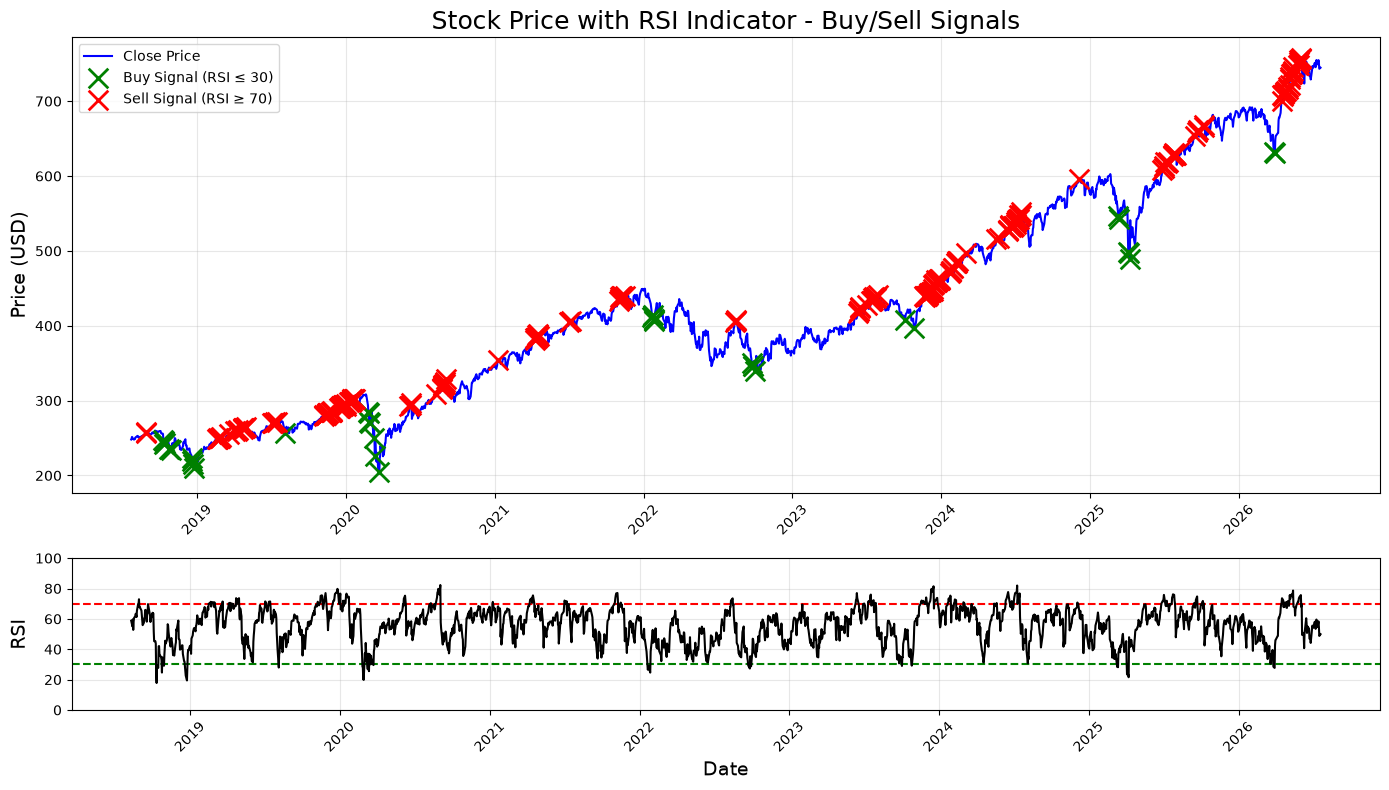

In [5]:
fig, ax = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, figsize=(14, 8))

# Top subplot: Close Price
ax[0].plot(mock_data['Close'], label='Close Price', linewidth=1.5, color='blue')

# Add buy signals (green X)
ax[0].scatter(mock_buy_signals.index, mock_buy_signals['Close'], marker='x', color='green', 
              s=200, linewidths=2, label='Buy Signal (RSI ≤ 30)', zorder=5)

# Add sell signals (red X)
ax[0].scatter(mock_sell_signals.index, mock_sell_signals['Close'], marker='x', color='red', 
              s=200, linewidths=2, label='Sell Signal (RSI ≥ 70)', zorder=5)

ax[0].set_title('Stock Price with RSI Indicator - Buy/Sell Signals', fontsize=18)
ax[0].set_ylabel('Price (USD)', fontsize=14)
ax[0].legend(fontsize=10, loc='upper left')
ax[0].grid(True, alpha=0.3)



# Bottom subplot: RSI
ax[1].axhline(y=70, color='red', ls='dashed', linewidth=1.5, label='Overbought (70)')
ax[1].axhline(y=30, color='green', ls='dashed', linewidth=1.5, label='Oversold (30)')
ax[1].plot(mock_data['RSI'], color='black', linewidth=1.5, label='RSI (14)')
ax[1].set_ylabel('RSI', fontsize=14)
ax[1].set_xlabel('Date', fontsize=14)
ax[1].set_ylim([0, 100])
#ax[1].legend(fontsize=10, loc='upper left')
ax[1].grid(True, alpha=0.3)

# Rotate x-axis labels for both subplots
plt.setp(ax[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(ax[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

# 1. Pairs Statistics & Selection

This section implements the first phase of pairs trading: data acquisition, cleaning, cointegration testing, spread estimation, and z-score calculation, producing `build_pairs_table` for later signal generation.

Pipeline: `download_adjusted_close` → `clean_price_data` → `test_cointegration` → `compute_hedge_ratio` → `compute_spread` → `compute_zscore` → `build_pairs_table`

`DEFAULT_PAIRS` is a placeholder list — replace with the team's final pair selections after cointegration testing.

`build_pairs_table` is the primary output of Section 1 — schema: `date, pair, asset_1, asset_2, alpha, beta, spread, z_score`


In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations

#   KO-PEP    Coca-Cola vs PepsiCo (beverages)
#   MA-V      Mastercard vs Visa (payments)
#   XOM-CVX   ExxonMobil vs Chevron (energy/oil)
#   TD-RY     TD Bank vs Royal Bank of Canada (Canadian banking)
#   SPY-QQQ   S&P 500 ETF vs Nasdaq-100 ETF (broad market indices)
DEFAULT_PAIRS = [("KO", "PEP"), ("MA", "V"), ("XOM", "CVX"), ("TD", "RY"), ("SPY", "QQQ")]

# Flatten DEFAULT_PAIRS, deduplicate, sort — produces the full ticker list needed for the price download
ALL_TICKERS = sorted({ticker for pair in DEFAULT_PAIRS for ticker in pair})
ALL_TICKERS

In [ ]:
def download_adjusted_close(tickers, start, end):
    if isinstance(tickers, str):
        tickers = [tickers]

    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)
    prices = raw["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame(name=tickers[0])

    return prices

In [ ]:
# Date range aligned with the project spec (2018-2026); end = today to get the most recent data
START_DATE = "2018-01-01"
END_DATE = dt.date.today().isoformat()

raw_prices = download_adjusted_close(ALL_TICKERS, START_DATE, END_DATE)
raw_prices.tail()

[*********************100%***********************]  10 of 10 completed


Ticker,CVX,KO,MA,PEP,QQQ,RY,SPY,TD,V,XOM
Date,,,,,,,,,,
2026-07-10,176.399994,83.489998,526.739990,137.380005,725.510010,211.089996,754.950012,120.529999,348.970001,138.880005
2026-07-13,182.199997,84.250000,537.700012,138.490005,711.739990,210.690002,749.169983,120.629997,357.750000,144.509995
2026-07-14,181.759995,83.080002,538.020020,135.449997,719.690002,214.039993,751.830017,122.879997,356.019989,145.089996
2026-07-15,181.600006,82.449997,535.210022,135.399994,717.739990,217.869995,754.809998,124.800003,355.140015,144.509995
2026-07-16,183.860001,84.919998,551.539978,139.429993,705.940002,216.070007,750.719971,123.900002,365.140015,145.949997


In [ ]:
"""
    Clean missing values from price data so downstream return and correlation
    calculations don't fail or produce incorrect results due to NaNs.

    Args:
      prices: pd.DataFrame, output of download_adjusted_close (may contain NaNs)

    Returns:
      pd.DataFrame, same column structure, but:
        - all-NaN columns removed
        - rows trimmed to the common valid date range across all tickers
        - no NaNs
"""

def clean_price_data(prices):
    # 1) Drop entirely-NaN columns (failed downloads)
    cleaned = prices.dropna(axis=1, how="all")

    # 2) Forward-fill sporadic missing trading days
    cleaned = cleaned.ffill()

    # 3) Trim to the latest common start date across all tickers
    common_start = max(cleaned[col].first_valid_index() for col in cleaned.columns)
    cleaned = cleaned.loc[common_start:]

    # 4) Sanity check: no NaNs should remain after cleaning
    assert cleaned.isna().sum().sum() == 0, "NaNs still present after clean_price_data"

    return cleaned

In [ ]:
prices = clean_price_data(raw_prices)
print(f"Clean date range: {prices.index.min().date()} ~ {prices.index.max().date()}, {len(prices)} trading days")
prices.tail()

Clean date range: 2018-01-02 ~ 2026-07-16, 2145 trading days


Ticker,CVX,KO,MA,PEP,QQQ,RY,SPY,TD,V,XOM
Date,,,,,,,,,,
2026-07-10,176.399994,83.489998,526.739990,137.380005,725.510010,211.089996,754.950012,120.529999,348.970001,138.880005
2026-07-13,182.199997,84.250000,537.700012,138.490005,711.739990,210.690002,749.169983,120.629997,357.750000,144.509995
2026-07-14,181.759995,83.080002,538.020020,135.449997,719.690002,214.039993,751.830017,122.879997,356.019989,145.089996
2026-07-15,181.600006,82.449997,535.210022,135.399994,717.739990,217.869995,754.809998,124.800003,355.140015,144.509995
2026-07-16,183.860001,84.919998,551.539978,139.429993,705.940002,216.070007,750.719971,123.900002,365.140015,145.949997


In [ ]:
"""
    Test whether a pair of price series is cointegrated using the Engle-Granger test.

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]

    Returns:
      dict: {"pair": str, "p_value": float, "is_cointegrated": bool}
"""
def test_cointegration(prices, pair):
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    _, p_value, _ = coint(s1, s2)
    return {
        "pair": f"{asset_1}-{asset_2}",
        "p_value": round(p_value, 4),
        "is_cointegrated": p_value < 0.05,
    }

In [ ]:
# Run cointegration test for all 5 pairs and display results as a table
cointegration_results = pd.DataFrame([test_cointegration(prices, pair) for pair in DEFAULT_PAIRS])
cointegration_results

,pair,p_value,is_cointegrated
0,KO-PEP,1.0000,False
1,MA-V,0.0357,True
2,XOM-CVX,0.0684,False
3,TD-RY,0.7004,False
4,SPY-QQQ,0.1728,False


In [ ]:
"""
    Estimate the hedge ratio via OLS regression of asset_1 price on asset_2 price.

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]

    Returns:
      tuple[float, float]: (alpha, beta)
        alpha: OLS intercept
        beta:  OLS slope (hedge ratio)
"""

def compute_hedge_ratio(prices, pair):
    asset_1, asset_2 = pair
    s1, s2 = prices[asset_1].dropna().align(prices[asset_2].dropna(), join="inner")
    model = sm.OLS(s1, sm.add_constant(s2)).fit()
    alpha = float(model.params["const"])
    beta  = float(model.params[asset_2])
    return alpha, beta

In [ ]:
"""
    Compute the spread (regression residual) between two assets.

    Formula: ε = P1 - (alpha + beta * P2)

    Args:
      prices: pd.DataFrame, cleaned prices
      pair: tuple[str, str]
      alpha: float, OLS intercept from compute_hedge_ratio
      beta:  float, OLS slope from compute_hedge_ratio

    Returns:
      pd.Series, index = Date, name = "ASSET1-ASSET2_spread"
"""

def compute_spread(prices, pair, alpha, beta):
    asset_1, asset_2 = pair
    spread = prices[asset_1] - (alpha + beta * prices[asset_2])
    spread.name = f"{asset_1}-{asset_2}_spread"
    return spread.dropna()

In [ ]:
"""
    Compute the z-score of the spread.

    Args:
      spread: pd.Series, output of compute_spread
      window: int or None (default None = static over full history)

    Returns:
      pd.Series, z-score values (NaN rows dropped)
"""
def compute_zscore(spread, window=None):
    if window is None:
        zscore = (spread - spread.mean()) / spread.std()
    else:
        rolling_mean = spread.rolling(window).mean()
        rolling_std  = spread.rolling(window).std()
        zscore = (spread - rolling_mean) / rolling_std
    return zscore.dropna()

In [ ]:
"""
    Run the full pairs analysis pipeline for all pairs and stack results into a single
    long-format pairs_table — the primary output of Section 1.

    For each pair: compute_hedge_ratio -> compute_spread -> compute_zscore.

    Args:
      prices: pd.DataFrame, cleaned prices (output of clean_price_data)
      pairs: list[tuple[str, str]], e.g. DEFAULT_PAIRS
      window: int or None; None = static z-score over full history (default), int = rolling

    Returns:
      pd.DataFrame with columns [date, pair, asset_1, asset_2, alpha, beta, spread, z_score]
"""

def build_pairs_table(prices, pairs, window=None):
    frames = []
    for pair in pairs:
        asset_1, asset_2 = pair
        alpha, beta = compute_hedge_ratio(prices, pair)
        spread      = compute_spread(prices, pair, alpha, beta)
        zscore      = compute_zscore(spread, window)

        frames.append(pd.DataFrame({
            "date":    spread.index,
            "pair":    f"{asset_1}-{asset_2}",
            "asset_1": asset_1,
            "asset_2": asset_2,
            "alpha":   alpha,
            "beta":    beta,
            "spread":  spread.values,
            "z_score": zscore.reindex(spread.index).values,
        }))

    pairs_table = pd.concat(frames, ignore_index=True)
    assert set(pairs_table.columns) == {"date", "pair", "asset_1", "asset_2", "alpha", "beta", "spread", "z_score"}
    return pairs_table

In [ ]:
pairs_table = build_pairs_table(prices, DEFAULT_PAIRS)
print(f"pairs_table: {len(pairs_table)} rows, {pairs_table['pair'].nunique()} pairs")
pairs_table.head(10)

pairs_table: 10725 rows, 5 pairs


,date,pair,asset_1,asset_2,alpha,beta,spread,z_score
0,2018-01-02,KO-PEP,KO,PEP,4.61572,0.361931,-2.400189,-0.307877
1,2018-01-03,KO-PEP,KO,PEP,4.61572,0.361931,-2.390964,-0.306693
2,2018-01-04,KO-PEP,KO,PEP,4.61572,0.361931,-2.059917,-0.264229
3,2018-01-05,KO-PEP,KO,PEP,4.61572,0.361931,-2.162107,-0.277337
4,2018-01-08,KO-PEP,KO,PEP,4.61572,0.361931,-2.026960,-0.260002
5,2018-01-09,KO-PEP,KO,PEP,4.61572,0.361931,-1.875087,-0.240521
6,2018-01-10,KO-PEP,KO,PEP,4.61572,0.361931,-1.831403,-0.234918
7,2018-01-11,KO-PEP,KO,PEP,4.61572,0.361931,-1.687728,-0.216488
8,2018-01-12,KO-PEP,KO,PEP,4.61572,0.361931,-1.742079,-0.223460
9,2018-01-16,KO-PEP,KO,PEP,4.61572,0.361931,-1.583228,-0.203084


# 2. Trading Strategy & Backtester

In [ ]:
data = 'abs'

In [ ]:
print(data)

abs


# 3. Risk Engine

In [ ]:
data = 14234

In [ ]:
print(data)

14234


# 4. Robustness & Integration